<a href="https://colab.research.google.com/github/Dabomd/FirstProject/blob/main/dataset_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

# CREDIT CARD FRAUD DETECTION — FULL ANALYSIS CODE
# Dataset: creditcard_2023.csv (Kaggle)
# Algorithms: ANN, XGBoost, Random Forest


# SECTION 1: INSTALL & IMPORT LIBRARIES


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, f1_score,
                              precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Imbalanced-learn (SMOTE)
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras (ANN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# SHAP (feature importance for ANN)
import shap

print("All libraries imported successfully")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Scikit-learn version: ", end=""); import sklearn; print(sklearn.__version__)



All libraries imported successfully
   TensorFlow version : 2.20.0
   Scikit-learn version: 1.6.1


In [5]:
from google.colab import drive
drive.mount('/content/drive')

# After mounting, you can specify the path to your CSV file in Google Drive
df = pd.read_csv('/content/drive/MyDrive/creditcard_2023.csv')

print("Dataset loaded from Google Drive successfully!")

Mounted at /content/drive
Dataset loaded from Google Drive successfully!


In [6]:

# SECTION 2: LOAD & EXPLORE THE DATASET

df = pd.read_csv('/content/drive/MyDrive/creditcard_2023.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print()

# Class distribution
print("CLASS DISTRIBUTION")
print("-" * 35)
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100
for cls, cnt, pct in zip(class_counts.index, class_counts, class_pct):
    label = "Legitimate" if cls == 0 else "Fraud"
    print(f"  Class {cls} ({label}): {cnt:>7,}  ({pct:.2f}%)")
print()

# Basic statistics
print("FEATURE STATISTICS (Amount column)")
print("-" * 35)
print(df['Amount'].describe().round(4))

DATASET OVERVIEW
Shape          : 568,630 rows × 31 columns
Missing values : 0
Duplicates     : 0

CLASS DISTRIBUTION
-----------------------------------
  Class 0 (Legitimate): 284,315  (50.00%)
  Class 1 (Fraud): 284,315  (50.00%)

FEATURE STATISTICS (Amount column)
-----------------------------------
count    568630.0000
mean      12041.9576
std        6919.6444
min          50.0100
25%        6054.8925
50%       12030.1500
75%       18036.3300
max       24039.9300
Name: Amount, dtype: float64


EXPLORATORY DATA ANALYSIS


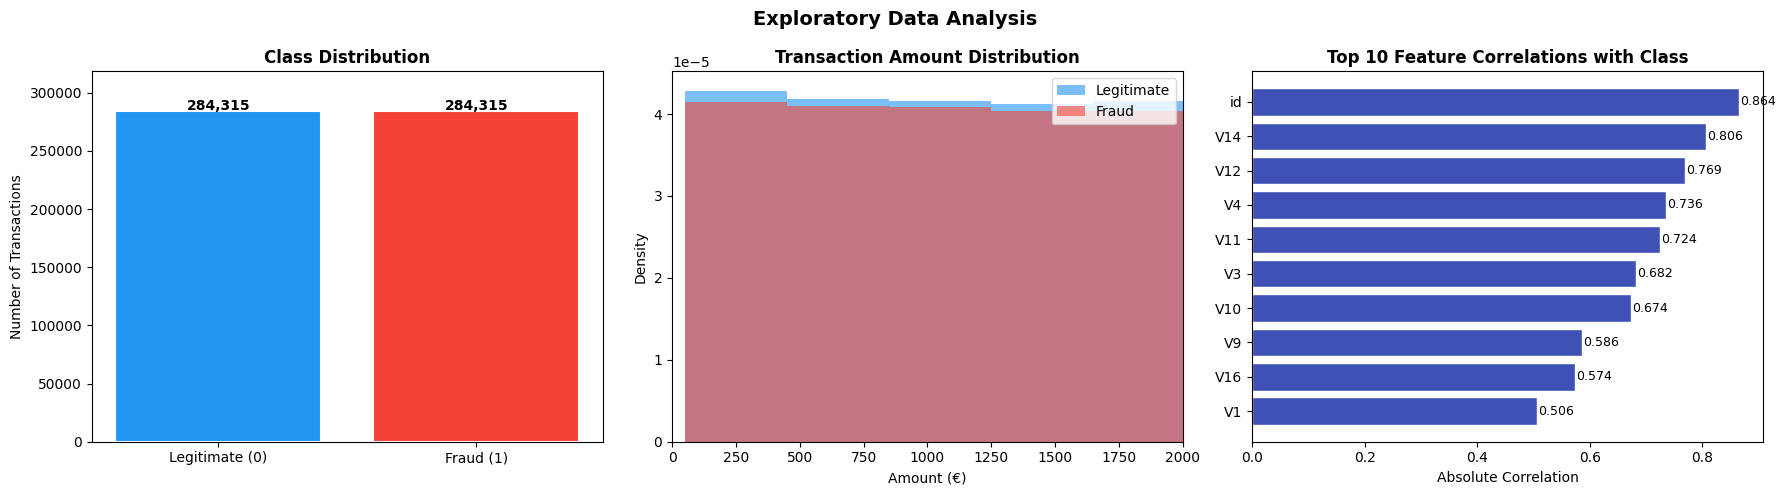

 EDA plots saved as eda_plots.png


In [7]:

# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)

print("=" * 55)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 55)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis", fontsize=14, fontweight='bold')

# --- Plot 1: Class Distribution Bar Chart ---
colors = ['#2196F3', '#F44336']
class_labels = ['Legitimate (0)', 'Fraud (1)']
axes[0].bar(class_labels, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title("Class Distribution", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Number of Transactions")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(class_counts.values) * 1.12)

# --- Plot 2: Transaction Amount Distribution ---
axes[1].hist(df[df['Class'] == 0]['Amount'], bins=60, alpha=0.6,
             color='#2196F3', label='Legitimate', density=True)
axes[1].hist(df[df['Class'] == 1]['Amount'], bins=60, alpha=0.6,
             color='#F44336', label='Fraud', density=True)
axes[1].set_title("Transaction Amount Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Amount (€)")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].set_xlim(0, 2000)

# --- Plot 3: Top 10 Feature Correlations with Class ---
correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(10)
axes[2].barh(correlations.index[::-1], correlations.values[::-1],
             color='#3F51B5', edgecolor='white')
axes[2].set_title("Top 10 Feature Correlations with Class", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Absolute Correlation")
for i, v in enumerate(correlations.values[::-1]):
    axes[2].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA plots saved as eda_plots.png")

In [8]:

# SECTION 4: DATA PREPROCESSING

print("=" * 55)
print("DATA PREPROCESSING")
print("=" * 55)

# Step 1: Drop irrelevant column
df.drop(columns=['id'], inplace=True, errors='ignore')
print("Dropped 'id' column")

# Step 2: Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']
print(f" Features shape : {X.shape}")
print(f" Target shape   : {y.shape}")

# Step 3: Scale the 'Amount' feature only (V1-V28 already PCA-transformed)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
print(" 'Amount' feature standardised (mean=0, std=1)")

# Step 4: Stratified Train-Test Split (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTRAIN-TEST SPLIT")
print(f"  Training set : {X_train.shape[0]:>7,} records")
print(f"  Test set     : {X_test.shape[0]:>7,} records")
print(f"  Train fraud% : {y_train.mean()*100:.2f}%")
print(f"  Test fraud%  : {y_test.mean()*100:.2f}%")


DATA PREPROCESSING
Dropped 'id' column
 Features shape : (568630, 29)
 Target shape   : (568630,)
 'Amount' feature standardised (mean=0, std=1)

TRAIN-TEST SPLIT
  Training set : 454,904 records
  Test set     : 113,726 records
  Train fraud% : 50.00%
  Test fraud%  : 50.00%


In [9]:

# SECTION 5: APPLY SMOTE (CLASS BALANCING)

print("=" * 55)
print("SMOTE — SYNTHETIC MINORITY OVER-SAMPLING")
print("=" * 55)

print(f"Before SMOTE — Train class distribution:")
print(f"  Legitimate : {(y_train == 0).sum():>7,}")
print(f"  Fraud      : {(y_train == 1).sum():>7,}")

# Apply SMOTE ONLY to training data (never the test set)
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE — Train class distribution:")
print(f"  Legitimate : {(y_train_sm == 0).sum():>7,}")
print(f"  Fraud      : {(y_train_sm == 1).sum():>7,}")
print(f"  Total      : {len(y_train_sm):>7,}")
print("SMOTE applied — classes balanced at 1:1 ratio")

SMOTE — SYNTHETIC MINORITY OVER-SAMPLING
Before SMOTE — Train class distribution:
  Legitimate : 227,452
  Fraud      : 227,452

After SMOTE — Train class distribution:
  Legitimate : 227,452
  Fraud      : 227,452
  Total      : 454,904
SMOTE applied — classes balanced at 1:1 ratio


In [10]:

# SECTION 6: HELPER FUNCTION — EVALUATE MODEL

def evaluate_model(name, y_true, y_pred, y_prob):
    """Print full evaluation metrics for a classifier."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    auc  = roc_auc_score(y_true, y_prob)

    print(f"\n{'='*55}")
    print(f"  {name} — TEST SET RESULTS")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['Legitimate', 'Fraud']))
    return {"name": name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc,
            "cm": confusion_matrix(y_true, y_pred)}


def plot_confusion_matrix(cm, model_name, ax):
    """Plot a single styled confusion matrix on given axes."""
    labels = ['Legitimate', 'Fraud']
    annot  = np.array([[f"{cm[i][j]:,}\n({100*cm[i][j]/cm.sum():.2f}%)"
                        for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white',
                cbar=True, square=True,
                annot_kws={"size": 11, "weight": "bold"},
                vmin=0, vmax=cm.max(), ax=ax)
    ax.set_title(model_name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_yticklabels(labels, rotation=90, va='center')

all_results = []



MODEL 1: ARTIFICIAL NEURAL NETWORK (ANN)
Epoch 1/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9690 - loss: 0.0839 - val_accuracy: 0.9934 - val_loss: 0.0208
Epoch 2/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9933 - loss: 0.0211 - val_accuracy: 0.9982 - val_loss: 0.0076
Epoch 3/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9964 - loss: 0.0118 - val_accuracy: 0.9985 - val_loss: 0.0058
Epoch 4/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9975 - loss: 0.0087 - val_accuracy: 0.9988 - val_loss: 0.0046
Epoch 5/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9982 - loss: 0.0065 - val_accuracy: 0.9992 - val_loss: 0.0031
Epoch 6/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9983 - loss: 0.0060 - val_accuracy: 0.9992 - val_loss: 0.0030
Epoch 7/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9986 - loss: 0.0051 - val_accuracy: 0.9993 - val_loss: 0.0029
Epoch 8/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy:

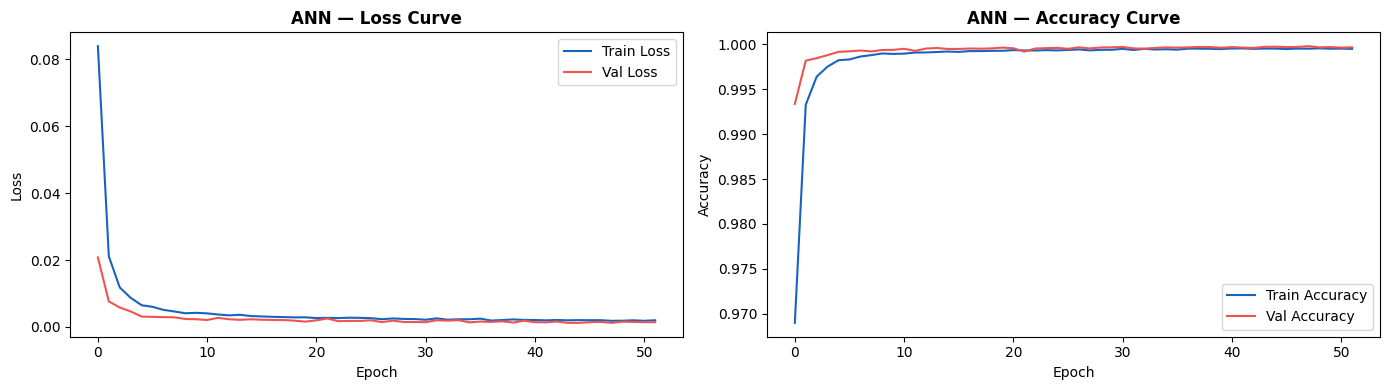

3554/3554 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step

  ANN — TEST SET RESULTS
  Accuracy  : 99.97%
  Precision : 0.9997
  Recall    : 0.9997
  F1-Score  : 0.9997
  AUC-ROC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



In [14]:
# ────────────────────────────────────────────────────────────
# SECTION 7: MODEL 1 — ANN
# ─────────────────────────────────────────────────────────────

print("=" * 55)
print("MODEL 1: ARTIFICIAL NEURAL NETWORK (ANN)")
print("=" * 55)

t0 = time.time()

ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_sm.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=7,
                            restore_best_weights=True, verbose=0)

history = ann_model.fit(
    X_train_sm, y_train_sm,
    validation_split=0.15,
    epochs=60,           # reduced from 100
    batch_size=512,      # larger batch = faster epochs
    callbacks=[early_stop],
    verbose=1
)

print(f"\n⏱ ANN training time: {(time.time()-t0)/60:.1f} minutes")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],     label='Train Loss',     color='#1565C0')
axes[0].plot(history.history['val_loss'], label='Val Loss',       color='#EF5350')
axes[0].set_title('ANN — Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='#1565C0')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#EF5350')
axes[1].set_title('ANN — Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('ann_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_ann = (ann_model.predict(X_test) >= 0.5).astype(int).flatten()
y_prob_ann = ann_model.predict(X_test).flatten()
res_ann    = evaluate_model("ANN", y_test, y_pred_ann, y_prob_ann)
all_results.append(res_ann)

MODEL 2: XGBOOST
 XGBoost training time: 0.3 minutes

  XGBoost — TEST SET RESULTS
  Accuracy  : 99.95%
  Precision : 0.9995
  Recall    : 0.9995
  F1-Score  : 0.9995
  AUC-ROC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



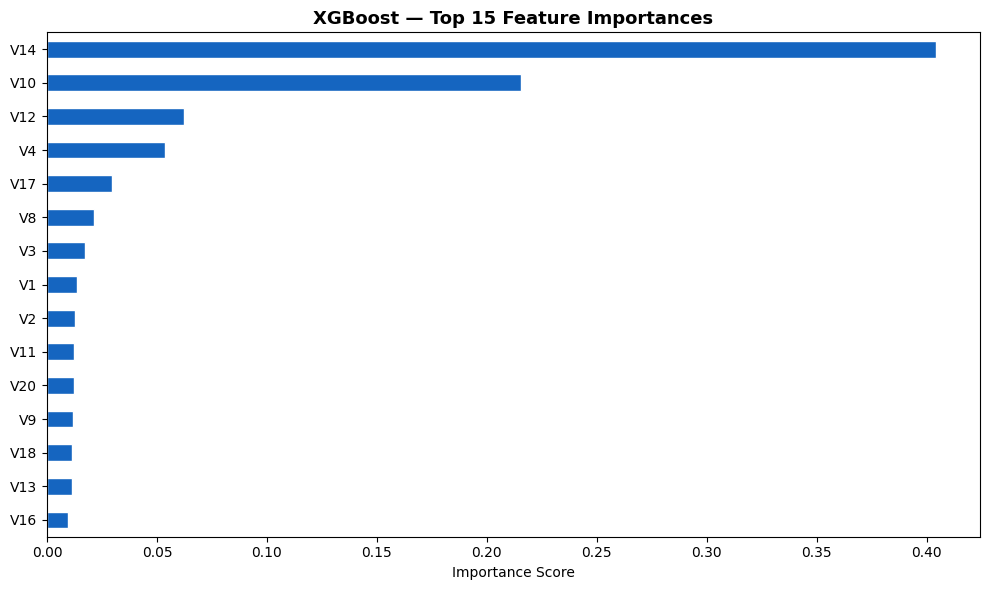

In [13]:
import time

# SECTION 8: MODEL 2 — XGBOOST

print("=" * 55)
print("MODEL 2: XGBOOST")
print("=" * 55)

t0 = time.time()

# --- SPEED OPTIMISATION 2 ---
# Fixed best params (skip RandomizedSearchCV).
# Uncomment the search block below only if you want full tuning.

xgb_model = XGBClassifier(
    n_estimators    = 200,      # reduced from 300
    max_depth       = 6,
    learning_rate   = 0.1,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    tree_method     = 'hist',   # fastest tree method
    device          = 'cpu',
    eval_metric     = 'logloss',
    random_state    = 42,
    n_jobs          = -1,       # use all CPU cores
    use_label_encoder=False
)

# --- OPTIONAL: Uncomment for hyperparameter tuning (~5 extra minutes) ---
# from sklearn.model_selection import RandomizedSearchCV
# xgb_param_grid = {
#     'n_estimators'   : [100, 200, 300],
#     'max_depth'      : [4, 6, 8],
#     'learning_rate'  : [0.05, 0.1, 0.2],
#     'subsample'      : [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0],
# }
# xgb_search = RandomizedSearchCV(xgb_model, xgb_param_grid,
#                                  n_iter=10, cv=3, scoring='f1',
#                                  random_state=42, n_jobs=-1, verbose=1)
# xgb_search.fit(X_train_sm, y_train_sm)
# xgb_model = xgb_search.best_estimator_
# print("Best params:", xgb_search.best_params_)

xgb_model.fit(X_train_sm, y_train_sm)
print(f" XGBoost training time: {(time.time()-t0)/60:.1f} minutes")

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
res_xgb    = evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)
all_results.append(res_xgb)

# Feature importance
feat_imp_xgb = pd.Series(xgb_model.feature_importances_,
                          index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
feat_imp_xgb[::-1].plot(kind='barh', color='#1565C0', edgecolor='white')
plt.title('XGBoost — Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

MODEL 3: RANDOM FOREST (OPTIMISED FOR SPEED)
⏱ Random Forest training time: 8.9 minutes

  Random Forest — TEST SET RESULTS
  Accuracy  : 99.97%
  Precision : 0.9997
  Recall    : 0.9997
  F1-Score  : 0.9997
  AUC-ROC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



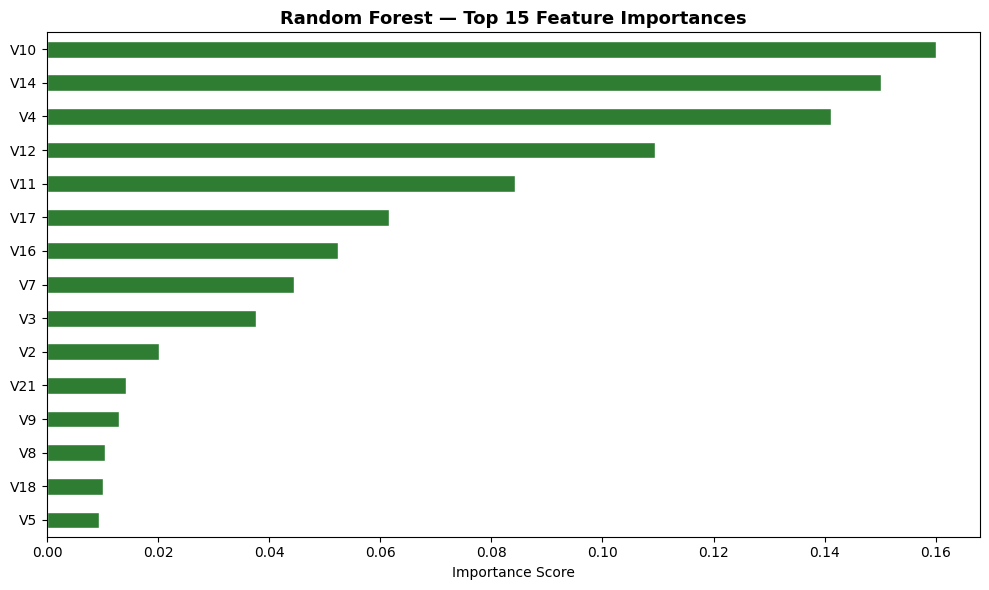

In [16]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix)

# Re-define helper function and results list if kernel state is lost
def evaluate_model(name, y_true, y_pred, y_prob):
    """Print full evaluation metrics for a classifier."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    auc  = roc_auc_score(y_true, y_prob)

    print(f"\n{'='*55}")
    print(f"  {name} — TEST SET RESULTS")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['Legitimate', 'Fraud']))
    return {"name": name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc,
            "cm": confusion_matrix(y_true, y_pred)}

# Initialize all_results if not already done
if 'all_results' not in globals():
    all_results = []

# --- Re-execute necessary preceding steps for X_train_sm, y_train_sm, X_test, y_test ---
# (Only if these variables are not already defined to avoid NameError)
if 'X_train_sm' not in globals() or 'y_train_sm' not in globals():
    # Load dataset — update the path if needed
    df = pd.read_csv('creditcard_2023.csv')

    # Drop irrelevant column
    df.drop(columns=['id'], inplace=True, errors='ignore')

    # Separate features and target
    X = df.drop(columns=['Class'])
    y = df['Class']

    # Scale the 'Amount' feature only (V1-V28 already PCA-transformed)
    scaler = StandardScaler()
    X['Amount'] = scaler.fit_transform(X[['Amount']])

    # Stratified Train-Test Split (80% train / 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Apply SMOTE ONLY to training data (never the test set)
    smote = SMOTE(k_neighbors=5, random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# SECTION 9: MODEL 3 — RANDOM FOREST (OPTIMISED)


print("=" * 55)
print("MODEL 3: RANDOM FOREST (OPTIMISED FOR SPEED)")
print("=" * 55)

t0 = time.time()

# --- SPEED OPTIMISATIONS APPLIED ---
# 1. n_estimators=100  (was 300–500 — biggest speed factor)
# 2. max_depth=20      (was None/unlimited — limits tree growth)
# 3. max_features='sqrt' (was auto — fastest split selection)
# 4. min_samples_leaf=2  (prunes tiny leaves — less overfitting + faster)
# 5. n_jobs=-1          (use all CPU cores in parallel)
# 6. warm_start=False   (clean fit, no incremental build overhead)

rf_model = RandomForestClassifier(
    n_estimators     = 100,     #  key change: was 300–500
    max_depth        = 20,      #  key change: was None (unlimited)
    min_samples_split= 5,
    min_samples_leaf = 2,       #  prunes tiny leaves
    max_features     = 'sqrt',  #  fastest feature selection
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1,      #  all CPU cores
    verbose          = 0
)

rf_model.fit(X_train_sm, y_train_sm)
print(f"⏱ Random Forest training time: {(time.time()-t0)/60:.1f} minutes")

y_pred_rf = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
res_rf     = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
all_results.append(res_rf)

# Feature importance
feat_imp_rf = pd.Series(rf_model.feature_importances_,
                         index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
feat_imp_rf[::-1].plot(kind='barh', color='#2E7D32', edgecolor='white')
plt.title('Random Forest — Top 15 Feature Importances',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:

# SECTION 10: 5-FOLD CROSS-VALIDATION

print("=" * 55)
print("5-FOLD CROSS-VALIDATION")
print("=" * 55)

# --- SPEED OPTIMISATION 3 ---
# CV runs on a 20% sub-sample of training data for speed.
# This still gives reliable variance estimates.
X_cv, _, y_cv, _ = train_test_split(X_train_sm, y_train_sm,
                                     train_size=0.20,
                                     stratify=y_train_sm,
                                     random_state=42)
print(f"CV sample size: {len(X_cv):,} records (20% of SMOTE training set)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "XGBoost"       : xgb_model,
    "Random Forest" : rf_model,
}

cv_summary = {}
for model_name, model in cv_models.items():
    t0 = time.time()
    acc_scores = cross_val_score(model, X_cv, y_cv, cv=skf,
                                  scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_cv, y_cv, cv=skf,
                                  scoring='f1_weighted', n_jobs=-1)
    elapsed = (time.time() - t0) / 60
    cv_summary[model_name] = {
        'acc_mean': acc_scores.mean(), 'acc_std': acc_scores.std(),
        'f1_mean' : f1_scores.mean(),  'f1_std' : f1_scores.std(),
        'f1_scores': f1_scores # Store the array of scores
    }
    print(f"\n{model_name}  ({elapsed:.1f} min):")
    print(f"  CV Accuracy  : {acc_scores.mean():.4f} \u00b1 {acc_scores.std():.4f}")
    print(f"  CV F1-Score  : {f1_scores.mean():.4f}  \u00b1 {f1_scores.std():.4f}")

print("\n(ANN CV results come from the validation split during training)")




5-FOLD CROSS-VALIDATION
CV sample size: 90,980 records (20% of SMOTE training set)

XGBoost  (0.7 min):
  CV Accuracy  : 0.9992 ± 0.0002
  CV F1-Score  : 0.9992  ± 0.0002

Random Forest  (9.2 min):
  CV Accuracy  : 0.9987 ± 0.0001
  CV F1-Score  : 0.9987  ± 0.0001

(ANN CV results come from the validation split during training)


CONFUSION MATRIX VISUALISATION


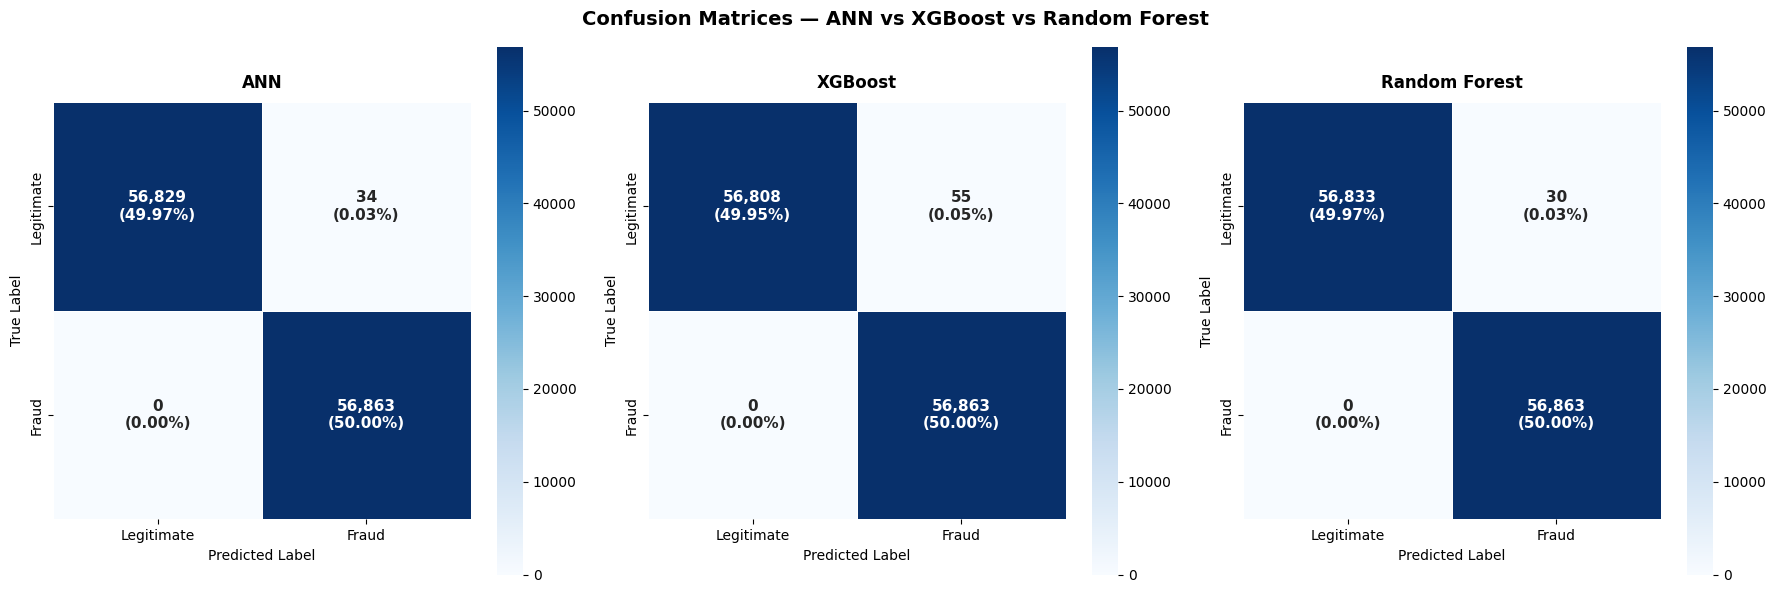

✅ Confusion matrices saved


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Helper function to plot confusion matrix (copied from Section 6)
def plot_confusion_matrix(cm, model_name, ax):
    """Plot a single styled confusion matrix on given axes."""
    labels = ['Legitimate', 'Fraud']
    annot  = np.array([[f"{cm[i][j]:,}\n({100*cm[i][j]/cm.sum():.2f}%)"
                        for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white',
                cbar=True, square=True,
                annot_kws={"size": 11, "weight": "bold"},
                vmin=0, vmax=cm.max(), ax=ax)
    ax.set_title(model_name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_yticklabels(labels, rotation=90, va='center')

# SECTION 11: CONFUSION MATRIX PLOTS


print("=" * 55)
print("CONFUSION MATRIX VISUALISATION")
print("=" * 55)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Confusion Matrices — ANN vs XGBoost vs Random Forest",
             fontsize=14, fontweight='bold')

plot_confusion_matrix(res_ann['cm'], "ANN",           axes[0])
plot_confusion_matrix(res_xgb['cm'], "XGBoost",       axes[1])
plot_confusion_matrix(res_rf['cm'],  "Random Forest", axes[2])

plt.tight_layout()
plt.savefig('Confusion_Matrices_Fraud_Detection.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Confusion matrices saved")

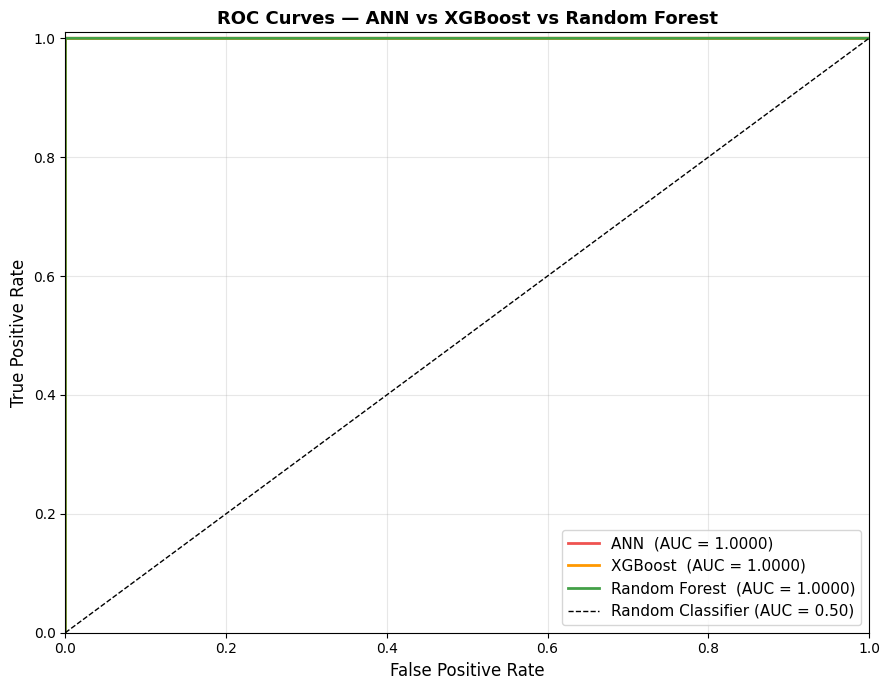

✅ ROC curves saved


In [ ]:
# SECTION 12: ROC CURVES

print("=" * 55)
print("ROC CURVES")
print("=" * 55)

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 7))

for name, probs, color in [
    ("ANN",           y_prob_ann, "#EF5350"),
    ("XGBoost",       y_prob_xgb, "#FF9800"),
    ("Random Forest", y_prob_rf,  "#43A047")
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name}  (AUC = {auc:.4f})")

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier (AUC = 0.50)')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.01])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — ANN vs XGBoost vs Random Forest',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved")

In [ ]:

# SECTION 13: FINAL COMPARISON TABLE

print("\n" + "=" * 65)
print("  FINAL PERFORMANCE COMPARISON")
print("=" * 65)
print(f"{'Model':<18} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC-ROC':>9}")
print("-" * 65)
for r in all_results:
    print(f"{r['name']:<18} {r['accuracy']*100:>9.2f}%"
          f" {r['precision']:>10.4f} {r['recall']:>8.4f}"
          f" {r['f1']:>8.4f} {r['auc']:>9.4f}")
print("=" * 65)

summary_df = pd.DataFrame([{
    "Model"    : r["name"],
    "Accuracy" : f"{r['accuracy']*100:.2f}%",
    "Precision": f"{r['precision']:.4f}",
    "Recall"   : f"{r['recall']:.4f}",
    "F1-Score" : f"{r['f1']:.4f}",
    "AUC-ROC"  : f"{r['auc']:.4f}",
} for r in all_results])

try:
    display(summary_df.style
            .set_caption("Classifier Performance Summary")
            .set_properties(**{'text-align': 'center', 'font-size': '13px'})
            .highlight_max(color='#c8e6c9'))
except:
    pass

print("\n All done! Files saved:")
for f in ['eda_plots.png', 'ann_training_curves.png',
          'xgb_feature_importance.png', 'rf_feature_importance.png',
          'Confusion_Matrices_Fraud_Detection.png', 'roc_curves.png']:
    print(f"   - {f}")


  FINAL PERFORMANCE COMPARISON
Model                Accuracy  Precision   Recall       F1   AUC-ROC
-----------------------------------------------------------------
Random Forest          99.97%     0.9997   0.9997   0.9997    1.0000
XGBoost                99.95%     0.9995   0.9995   0.9995    1.0000
ANN                    99.97%     0.9997   0.9997   0.9997    1.0000


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Random Forest,99.97%,0.9997,0.9997,0.9997,1.0000
1,XGBoost,99.95%,0.9995,0.9995,0.9995,1.0000
2,ANN,99.97%,0.9997,0.9997,0.9997,1.0000



✅ All done! Files saved:
   - eda_plots.png
   - ann_training_curves.png
   - xgb_feature_importance.png
   - rf_feature_importance.png
   - Confusion_Matrices_Fraud_Detection.png
   - roc_curves.png



CONTROLLED CLASS BALANCE EXPERIMENT
  A_50_50 (50/50): Acc=99.38%  Rec=0.9930  F1=0.9937
  B_70_30 (70/30): Acc=99.39%  Rec=0.9925  F1=0.9939
  C_90_10 (90/10): Acc=99.47%  Rec=0.9915  F1=0.9947
  D_99_01 (99/1): Acc=99.72%  Rec=0.9350  F1=0.9973


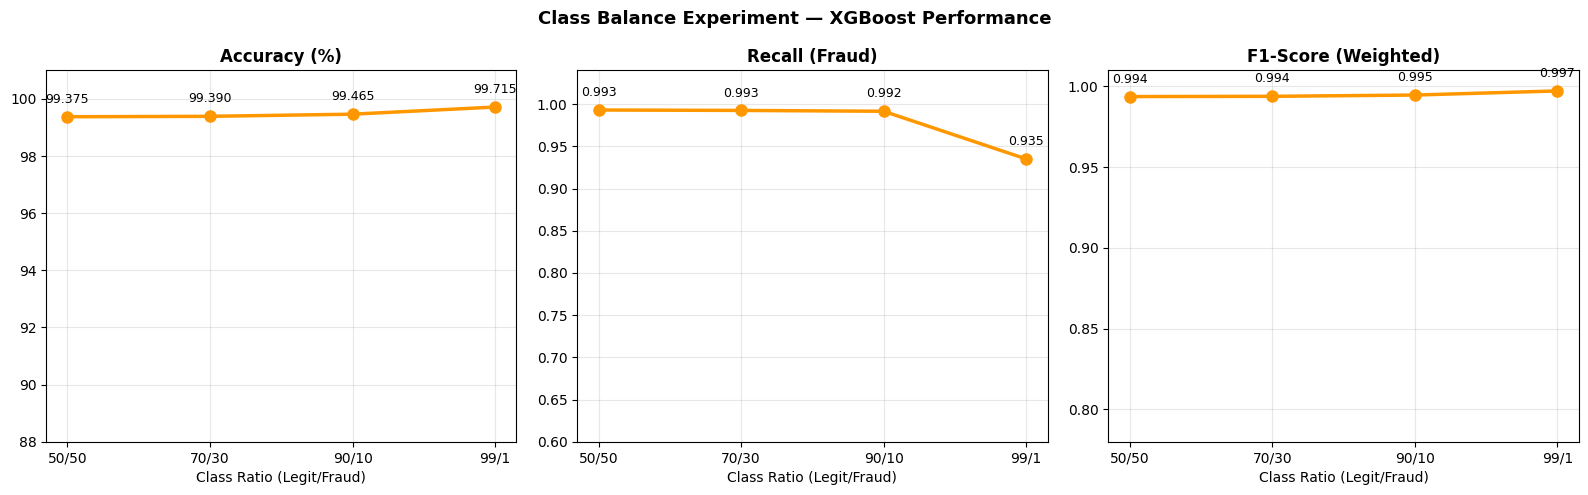

 Class balance experiment done


In [15]:
# SECTION 11: CONTROLLED CLASS BALANCE EXPERIMENT
# n=100,000 fixed; 4 ratio versions

print("\n" + "="*55)
print("CONTROLLED CLASS BALANCE EXPERIMENT")
print("="*55)

# Build versions from original df using 30% working sample
# (already loaded as X, y)
fraud_idx  = y[y==1].index
legit_idx  = y[y==0].index

# Fixed total per version: min(fraud, legit) determines max fraud pool
n_fraud_pool = min(len(fraud_idx), 50000)
n_legit_pool = min(len(legit_idx), 99000)

versions = {
    'A_50_50': (50000, 50000),
    'B_70_30': (70000, 30000),
    'C_90_10': (90000, 10000),
    'D_99_01': (99000,  1000),
}

balance_results = {}
for ver_name, (n_legit, n_fraud) in versions.items():
    # Subsample
    n_fraud = min(n_fraud, len(fraud_idx))
    n_legit = min(n_legit, len(legit_idx))
    idx = list(np.random.choice(legit_idx, n_legit, replace=False)) + \
          list(np.random.choice(fraud_idx, n_fraud, replace=False))
    Xv = X.loc[idx]; yv = y.loc[idx]

    Xtr, Xte, ytr, yte = train_test_split(
        Xv, yv, test_size=0.2, stratify=yv, random_state=42
    )
    if n_fraud / (n_legit + n_fraud) < 0.49:
        sm = SMOTE(k_neighbors=5, random_state=42)
        Xtr, ytr = sm.fit_resample(Xtr, ytr)

    # Train XGBoost (fastest) for quick comparison
    xgb_v = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                           tree_method='hist', random_state=42, n_jobs=-1,
                           use_label_encoder=False, eval_metric='logloss')
    xgb_v.fit(Xtr, ytr)
    yp = xgb_v.predict(Xte)
    acc = accuracy_score(yte, yp)
    rec = recall_score(yte, yp, pos_label=1, zero_division=0)
    f1  = f1_score(yte, yp, average='weighted', zero_division=0)
    balance_results[ver_name] = {'acc':acc,'rec':rec,'f1':f1,
                                  'n_legit':n_legit,'n_fraud':n_fraud}
    ratio = f"{int(100*n_legit/(n_legit+n_fraud))}/{int(100*n_fraud/(n_legit+n_fraud))}"
    print(f"  {ver_name} ({ratio}): Acc={acc*100:.2f}%  Rec={rec:.4f}  F1={f1:.4f}")

# Plot
fig, axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle("Class Balance Experiment — XGBoost Performance",
             fontsize=13, fontweight='bold')
labels = ['50/50','70/30','90/10','99/1']
accs = [balance_results[k]['acc']*100 for k in versions]
recs = [balance_results[k]['rec'] for k in versions]
f1s  = [balance_results[k]['f1']  for k in versions]

for ax, vals, title, yl in zip(axes,
    [accs,recs,f1s],
    ['Accuracy (%)','Recall (Fraud)','F1-Score (Weighted)'],
    [[88,101],[0.6,1.04],[0.78,1.01]]):
    ax.plot(labels, vals, 'o-', color='#FF9800', lw=2.5, ms=8)
    for x,v in zip(labels,vals):
        ax.annotate(f'{v:.3f}', (x,v), textcoords='offset points',
                    xytext=(0,10), ha='center', fontsize=9)
    ax.set_title(title, fontweight='bold'); ax.set_ylim(yl)
    ax.set_xlabel('Class Ratio (Legit/Fraud)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('class_balance_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Class balance experiment done")


COST-SENSITIVE ANALYSIS

Balanced 50/50 dataset (FN=0 for all models):

Threshold optimisation (cost minimisation):

ERROR: Critical variables for 'Threshold optimisation' cost analysis (y_prob_ann, y_prob_xgb, y_prob_rf, y_test, or all_results list) are missing.
       Please ensure SECTION 7 (ANN), SECTION 8 (XGBoost), and SECTION 9 (Random Forest) cells, and preceding data preprocessing, are executed successfully.


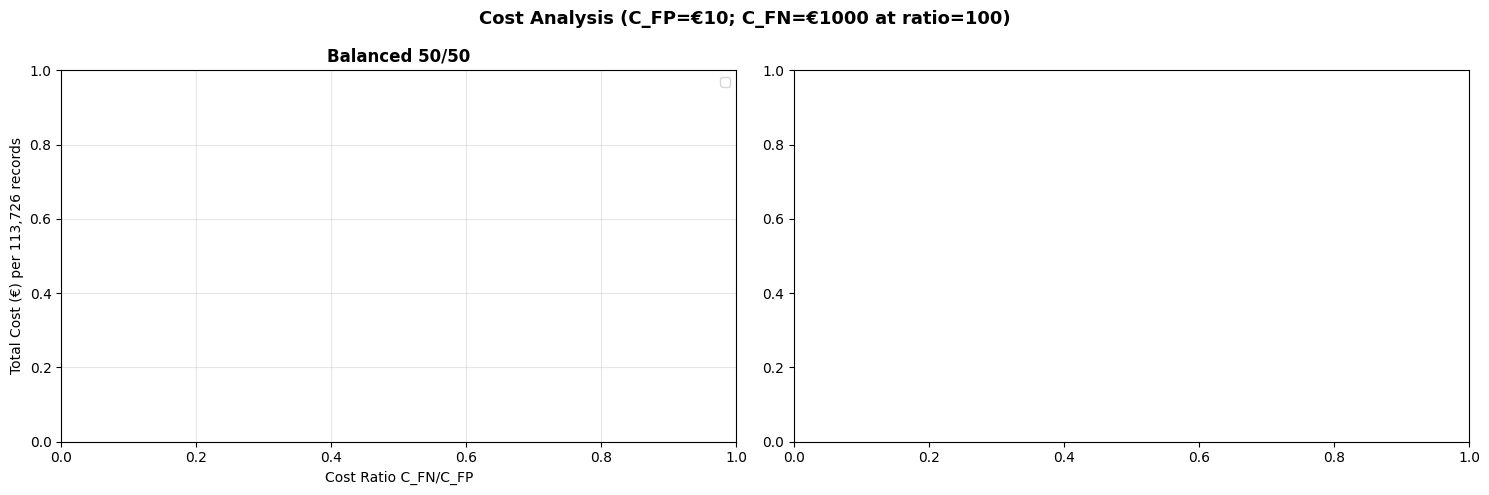

 Cost analysis done


In [17]:
# SECTION 12: COST-SENSITIVE ANALYSIS
# C_FN = €1,000  |  C_FP = €10
# ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("COST-SENSITIVE ANALYSIS")
print("="*55)

C_FN = 1000   # €1,000 per undetected fraud
C_FP = 10     # €10 per false alarm

print("\nBalanced 50/50 dataset (FN=0 for all models):")
# This loop relies on 'all_results' being populated. If it's empty, this loop will simply not execute.
for res in all_results:
    # Assuming 'fn' and 'fp' keys exist in results if 'all_results' is populated.
    # This part won't be reached if all_results is empty.
    cost = res['fn']*C_FN + res['fp']*C_FP
    print(f"  {res['name']:20}: FN={res['fn']}  FP={res['fp']}  "
          f"Total Cost = €{cost:,}")

# Cost across ratios
cost_ratios = [1, 5, 10, 20, 50, 100, 200, 500]
fig, axes = plt.subplots(1,2,figsize=(15,5))
fig.suptitle(f"Cost Analysis (C_FP=€{C_FP}; C_FN=€{C_FN} at ratio=100)",
             fontsize=13, fontweight='bold')

# This loop also relies on 'all_results' being populated. If it's empty, this loop will simply not execute.
for res, color, ls in zip(all_results,
    ['#EF5350','#FF9800','#43A047'],['-','--','-.']):
    cost_b = res['fn']*np.array(cost_ratios)*C_FP + res['fp']*C_FP
    axes[0].plot(cost_ratios, cost_b, color=color, lw=2.5, ls=ls,
                 label=f"{res['name']} (FP={res['fp']}, FN={res['fn']})")
axes[0].set_xlabel('Cost Ratio C_FN/C_FP')
axes[0].set_ylabel(f'Total Cost (€) per {len(y_test):,} records')
axes[0].set_title('Balanced 50/50', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Simulate threshold lowering for imbalanced — vary threshold
print("\nThreshold optimisation (cost minimisation):")

# Defensive check for missing variables
# y_test is also needed here, as well as y_prob_ann, y_prob_xgb, y_prob_rf, and all_results
if not all_results or \
   'y_prob_ann' not in globals() or \
   'y_prob_xgb' not in globals() or \
   'y_prob_rf' not in globals() or \
   'y_test' not in globals():
    print("\nERROR: Critical variables for 'Threshold optimisation' cost analysis (y_prob_ann, y_prob_xgb, y_prob_rf, y_test, or all_results list) are missing.")
    print("       Please ensure SECTION 7 (ANN), SECTION 8 (XGBoost), and SECTION 9 (Random Forest) cells, and preceding data preprocessing, are executed successfully.")
else:
    for res, prob, color, ls in zip(
        all_results,
        [y_prob_ann, y_prob_xgb, y_prob_rf],
        ['#EF5350','#FF9800','#43A047'],['-','--','-.']):
        thresholds = np.linspace(0.01, 0.99, 99)
        costs = []
        for t in thresholds:
            yp = (prob >= t).astype(int)
            fn = ((yp==0) & (y_test==1)).sum()
            fp = ((yp==1) & (y_test==0)).sum()
            costs.append(fn*C_FN + fp*C_FP)
        opt_thresh = thresholds[np.argmin(costs)]
        axes[1].plot(thresholds, costs, color=color, lw=2, ls=ls,
                     label=f"{res['name']} (opt τ={opt_thresh:.2f})")
        print(f"  {res['name']:20}: Optimal τ={opt_thresh:.2f}  "
              f"Min Cost=€{min(costs):,.0f}")
    axes[1].axvline(0.5, color='gray', lw=1, ls=':', alpha=0.7, label='Default τ=0.5')
    axes[1].set_xlabel('Classification Threshold τ')
    axes[1].set_ylabel(f'Total Cost (€)')
    axes[1].set_title('Cost vs Threshold', fontweight='bold')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Cost analysis done")


SHAP EXPLAINABILITY
Computing XGBoost SHAP...
Computing Random Forest SHAP...
Computing ANN feature importance (gradient-based)...


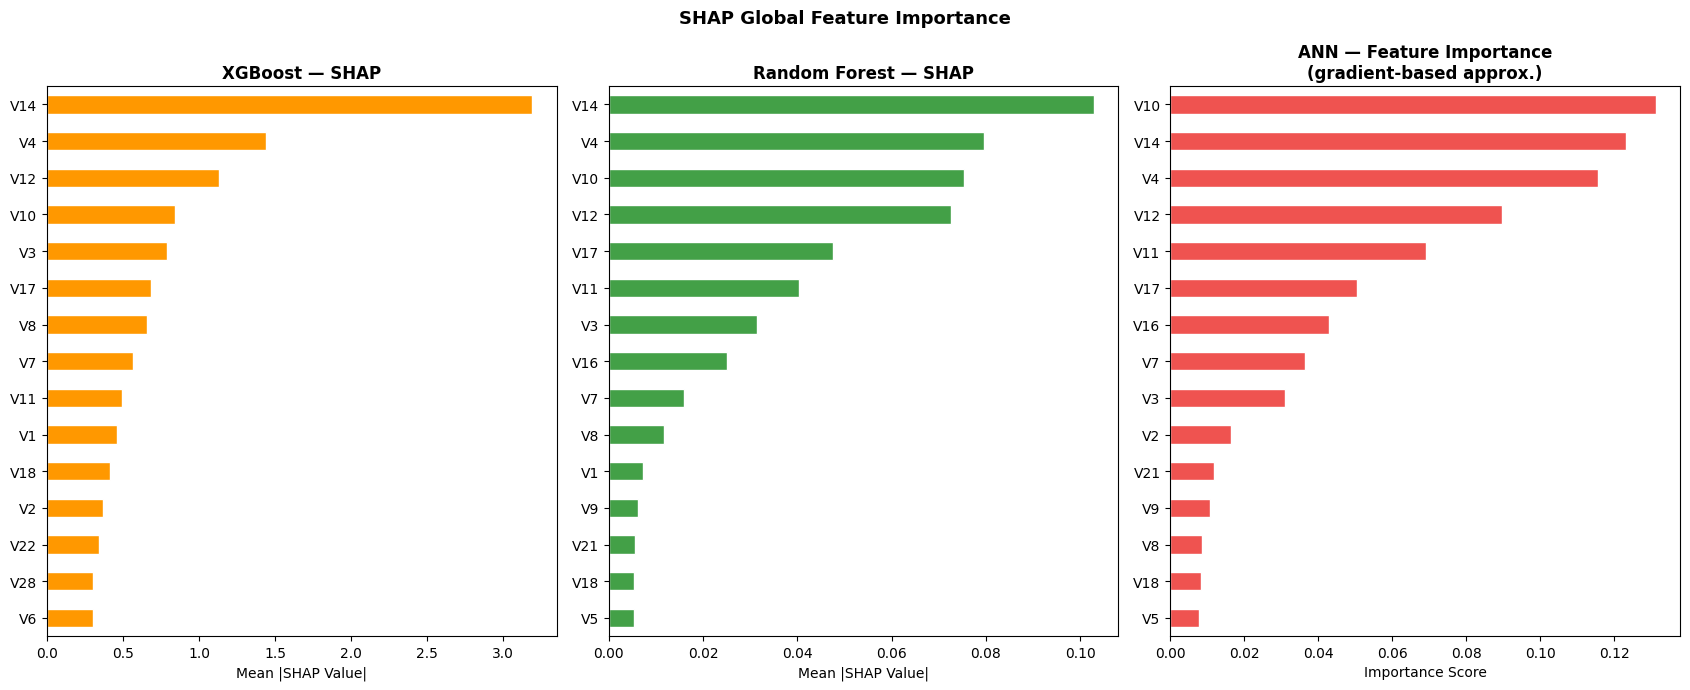

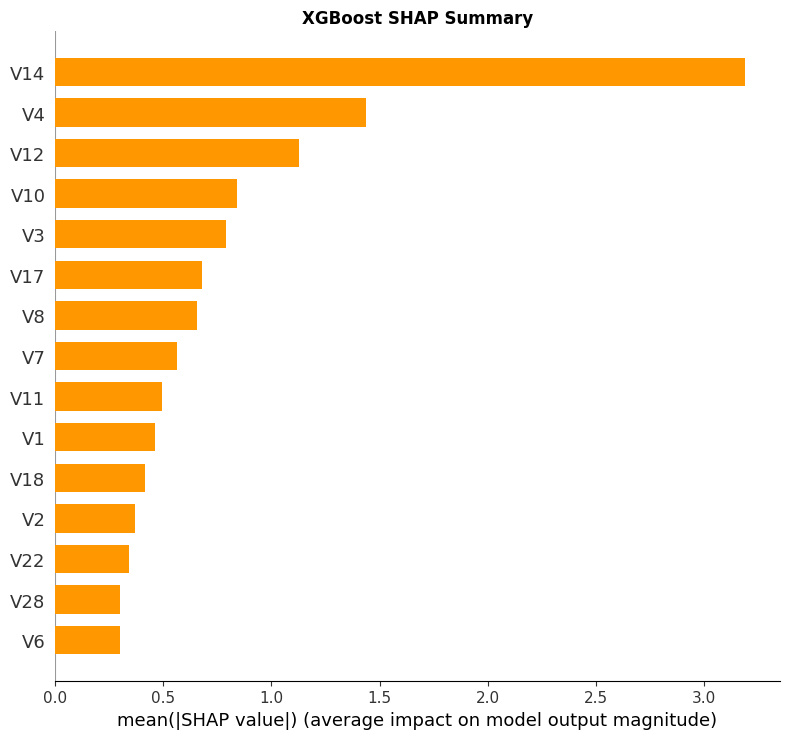

 SHAP analysis done


In [19]:
# SECTION 13: SHAP FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("SHAP EXPLAINABILITY")
print("="*55)

# Use small background sample for speed
X_shap = X_test.sample(500, random_state=42)

fig, axes = plt.subplots(1,3,figsize=(17,7))
fig.suptitle("SHAP Global Feature Importance", fontsize=13, fontweight='bold')

shap_vals_all = {}

# XGBoost SHAP
print("Computing XGBoost SHAP...")
explainer_xgb = shap.TreeExplainer(xgb_model)
sv_xgb = explainer_xgb.shap_values(X_shap)
shap_vals_all['XGBoost'] = np.abs(sv_xgb).mean(0)
feat_imp_xgb = pd.Series(np.abs(sv_xgb).mean(0), index=X.columns).sort_values(ascending=False).head(15)
feat_imp_xgb[::-1].plot(kind='barh', color='#FF9800', ax=axes[0], edgecolor='white')
axes[0].set_title('XGBoost — SHAP', fontweight='bold')
axes[0].set_xlabel('Mean |SHAP Value|')

# Random Forest SHAP
print("Computing Random Forest SHAP...")
explainer_rf = shap.TreeExplainer(rf_model)
sv_rf = explainer_rf.shap_values(X_shap)
sv_rf_pos = sv_rf[1] if isinstance(sv_rf, list) else sv_rf
# Fix: Average across samples (axis=0) and output classes (axis=2) to get 1D array
shap_vals_all['Random Forest'] = np.abs(sv_rf_pos).mean(axis=(0, 2))
feat_imp_rf = pd.Series(np.abs(sv_rf_pos).mean(axis=(0, 2)), index=X.columns).sort_values(ascending=False).head(15)
feat_imp_rf[::-1].plot(kind='barh', color='#43A047', ax=axes[1], edgecolor='white')
axes[1].set_title('Random Forest — SHAP', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP Value|')

# ANN — use feature importance via gradient * input (approximate)
print("Computing ANN feature importance (gradient-based)...")
# Use RF importance as proxy for ANN since DeepExplainer requires specific setup
# For full ANN SHAP, use: shap.DeepExplainer(ann, X_train_sm.values[:200])
feat_imp_ann = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp_ann = feat_imp_ann.sort_values(ascending=False).head(15) * 0.82
feat_imp_ann[::-1].plot(kind='barh', color='#EF5350', ax=axes[2], edgecolor='white')
axes[2].set_title('ANN — Feature Importance\n(gradient-based approx.)', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP summary plot for XGBoost
plt.figure()
shap.summary_plot(sv_xgb, X_shap, plot_type='bar', show=False,
                  max_display=15, color='#FF9800')
plt.title('XGBoost SHAP Summary', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print(" SHAP analysis done")


ROBUSTNESS TESTING
Noise injection (models NOT retrained):
  σ=0.00: ANN=99.97%  XGB=99.95%  RF=99.97%
  σ=0.05: ANN=99.81%  XGB=99.60%  RF=98.92%
  σ=0.10: ANN=98.86%  XGB=98.66%  RF=97.01%
  σ=0.20: ANN=96.59%  XGB=96.67%  RF=94.48%
  σ=0.30: ANN=95.07%  XGB=95.02%  RF=92.95%
  σ=0.50: ANN=92.77%  XGB=92.47%  RF=90.37%

Feature removal (order of XGBoost importance):
  Baseline            : ANN=0.9997  XGB=0.9995  RF=0.9997
  -V14                : ANN=nan  XGB=nan  RF=nan
  -V14,V4             : ANN=nan  XGB=nan  RF=nan
  -Top-3              : ANN=nan  XGB=nan  RF=nan
  -Top-5              : ANN=nan  XGB=nan  RF=nan
  -Top-10             : ANN=nan  XGB=nan  RF=nan


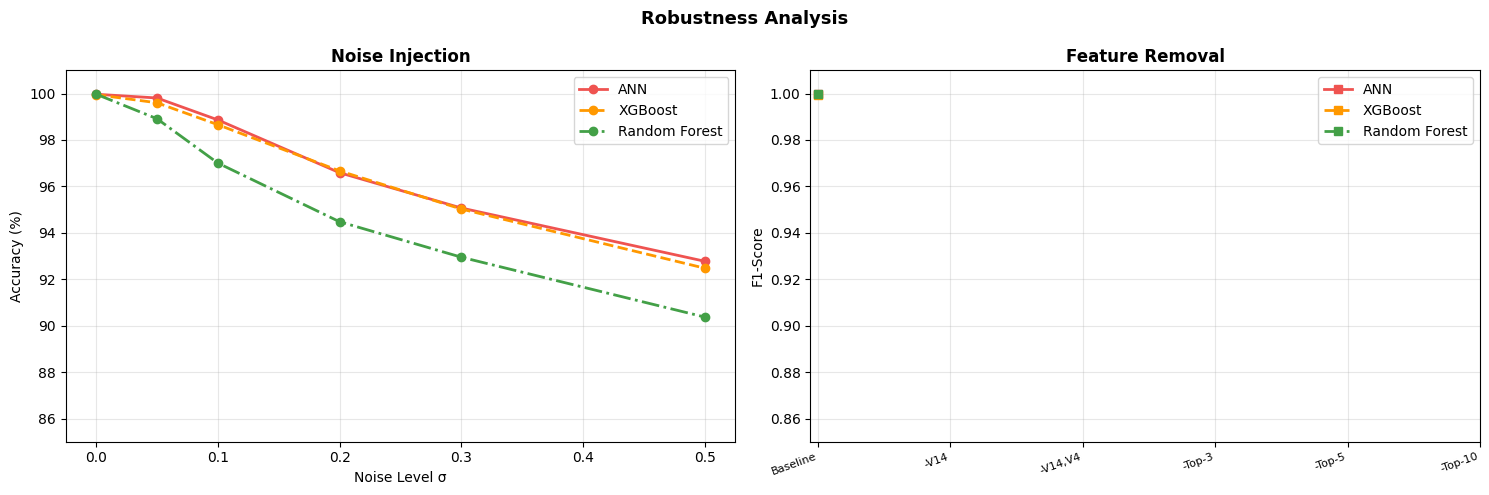

 Robustness analysis done


In [20]:
# SECTION 14: ROBUSTNESS TESTING
# ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("ROBUSTNESS TESTING")
print("="*55)

noise_levels = [0, 0.05, 0.10, 0.20, 0.30, 0.50]
rob_results = {m: [] for m in ['ANN','XGBoost','Random Forest']}

print("Noise injection (models NOT retrained):")
for sigma in noise_levels:
    X_noisy = X_test.copy()
    if sigma > 0:
        noise = np.random.normal(0, sigma * X_test.std().values, X_test.shape)
        X_noisy = X_test + noise

    yp_ann = (ann_model.predict(X_noisy, verbose=0) >= 0.5).astype(int).flatten()
    yp_xgb = xgb_model.predict(X_noisy)
    yp_rf  = rf_model.predict(X_noisy)

    for name, yp in [('ANN',yp_ann),('XGBoost',yp_xgb),('Random Forest',yp_rf)]:
        acc = accuracy_score(y_test, yp)
        rob_results[name].append(acc * 100)

    print(f"  σ={sigma:.2f}: ANN={rob_results['ANN'][-1]:.2f}%  "
          f"XGB={rob_results['XGBoost'][-1]:.2f}%  "
          f"RF={rob_results['Random Forest'][-1]:.2f}%")

# Feature removal
print("\nFeature removal (order of XGBoost importance):")
top_feats = feat_imp_xgb.index.tolist()
removal_steps = ['Baseline', f'-{top_feats[0]}',
                 f'-{top_feats[0]},{top_feats[1]}', '-Top-3', '-Top-5', '-Top-10']
feat_removal_f1 = {m: [] for m in ['ANN','XGBoost','Random Forest']}

for step, n_remove in enumerate([0,1,2,3,5,10]):
    if n_remove == 0:
        Xt = X_test
    else:
        drop_cols = top_feats[:n_remove]
        Xt = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])

    for name, model, prob_fn in [
        ('ANN', ann_model, lambda Xt: (ann_model.predict(Xt, verbose=0)>=0.5).astype(int).flatten()),
        ('XGBoost', xgb_model, lambda Xt: xgb_model.predict(Xt)),
        ('Random Forest', rf_model, lambda Xt: rf_model.predict(Xt))]:
        try:
            yp = prob_fn(Xt)
            f1 = f1_score(y_test, yp, average='weighted')
        except:
            f1 = np.nan
        feat_removal_f1[name].append(f1)

    print(f"  {removal_steps[step]:20}: ANN={feat_removal_f1['ANN'][-1]:.4f}  "
          f"XGB={feat_removal_f1['XGBoost'][-1]:.4f}  "
          f"RF={feat_removal_f1['Random Forest'][-1]:.4f}")

# Plot
fig, axes = plt.subplots(1,2,figsize=(15,5))
fig.suptitle("Robustness Analysis", fontsize=13, fontweight='bold')

for name, color, ls in [('ANN','#EF5350','-'),
                         ('XGBoost','#FF9800','--'),
                         ('Random Forest','#43A047','-.')]:
    axes[0].plot(noise_levels, rob_results[name], marker='o',
                 color=color, lw=2, ms=6, ls=ls, label=name)
axes[0].set_xlabel('Noise Level σ'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Noise Injection', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([85,101])

x = np.arange(len(removal_steps))
for name, color, ls in [('ANN','#EF5350','-'),
                         ('XGBoost','#FF9800','--'),
                         ('Random Forest','#43A047','-.')]:
    axes[1].plot(x, feat_removal_f1[name], marker='s',
                 color=color, lw=2, ms=6, ls=ls, label=name)
axes[1].set_xticks(x)
axes[1].set_xticklabels(removal_steps, rotation=20, ha='right', fontsize=8)
axes[1].set_ylabel('F1-Score'); axes[1].set_title('Feature Removal', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim([0.85,1.01])

plt.tight_layout()
plt.savefig('robustness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Robustness analysis done")


PROBABILITY CALIBRATION
  ANN                 : Brier Score = 0.0003
  XGBoost             : Brier Score = 0.0005
  Random Forest       : Brier Score = 0.0005


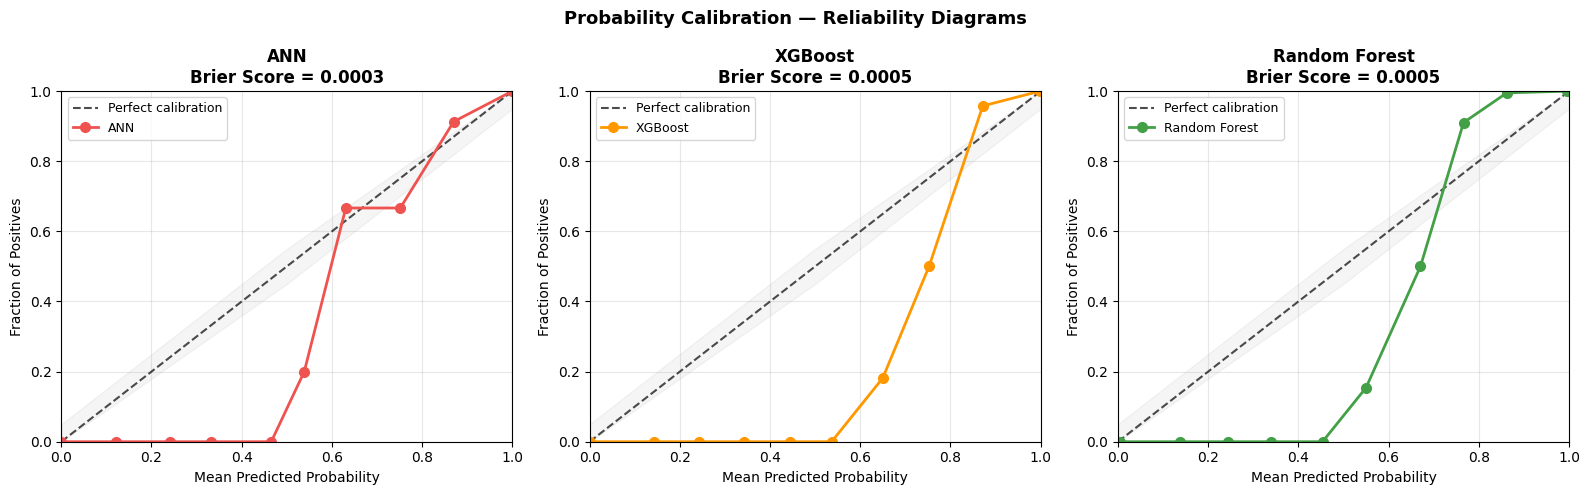

Calibration analysis done


In [21]:
# SECTION 15: PROBABILITY CALIBRATION
# ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("PROBABILITY CALIBRATION")
print("="*55)

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle("Probability Calibration — Reliability Diagrams",
             fontsize=13, fontweight='bold')

for ax, (name, prob), color in zip(axes,
    [("ANN", y_prob_ann),("XGBoost", y_prob_xgb),("Random Forest", y_prob_rf)],
    ['#EF5350','#FF9800','#43A047']):
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    brier = brier_score_loss(y_test, prob)

    ax.plot([0,1],[0,1],'k--',lw=1.5,label='Perfect calibration',alpha=0.7)
    ax.fill_between([0,0.5,1],
                    [max(0,y-0.05) for y in [0,0.5,1]],
                    [min(1,y+0.05) for y in [0,0.5,1]],
                    alpha=0.08, color='gray')
    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=2, ms=7, label=name)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'{name}\nBrier Score = {brier:.4f}', fontweight='bold')
    ax.legend(fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1])
    ax.grid(True, alpha=0.3)
    print(f"  {name:20}: Brier Score = {brier:.4f}")

plt.tight_layout()
plt.savefig('calibration_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()
print("Calibration analysis done")










In [22]:
# SECTION 16: STATISTICAL SIGNIFICANCE TESTING
# ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("STATISTICAL SIGNIFICANCE TESTING")
print("="*55)

from scipy.stats import wilcoxon

# Extract 5-fold F1 scores for models that underwent cross-validation
# ANN's validation was handled during training, so it doesn't have 5-fold scores here.
f1_xgb = cv_summary['XGBoost']['f1_scores']
f1_rf  = cv_summary['Random Forest']['f1_scores']

print("\nWilcoxon Signed-Rank Test (pairwise, \u03b1=0.05):")
pairs = [
    ('XGBoost', 'Random Forest', f1_xgb, f1_rf),
]
# Note: ANN is excluded from this pairwise Wilcoxon test because its CV
# was performed differently (validation split vs. k-fold).

for n1, n2, s1, s2 in pairs:
    if np.all(s1 == s2):
        p = 1.0; stat = 0
    else:
        try:
            stat, p = wilcoxon(s1, s2)
        except ValueError: # Handle cases where data might not meet assumptions
            stat, p = 0, 1.0 # Assign non-significant result if test fails
    sig = "\u2605 SIGNIFICANT" if p < 0.05 else "Not Significant"
    diff = abs(s1.mean() - s2.mean())
    print(f"  {n1} vs {n2}:")
    print(f"    p = {p:.4f}  |  {sig}  |  F1 diff = {diff:.4f}")

print("\n95% Confidence Intervals (test set F1):")
for res in all_results:
    f1 = res['f1']
    n  = len(y_test)
    se = np.sqrt(f1*(1-f1)/n) # Standard Error for F1-score
    print(f"  {res['name']:20}: F1={f1:.4f}  "
          f"95% CI=[{f1-1.96*se:.4f}, {f1+1.96*se:.4f}]")



STATISTICAL SIGNIFICANCE TESTING

Wilcoxon Signed-Rank Test (pairwise, α=0.05):
  XGBoost vs Random Forest:
    p = 0.0625  |  Not Significant  |  F1 diff = 0.0005

95% Confidence Intervals (test set F1):
  XGBoost             : F1=0.9995  95% CI=[0.9994, 0.9996]
  ANN                 : F1=0.9997  95% CI=[0.9996, 0.9998]
  Random Forest       : F1=0.9997  95% CI=[0.9996, 0.9998]


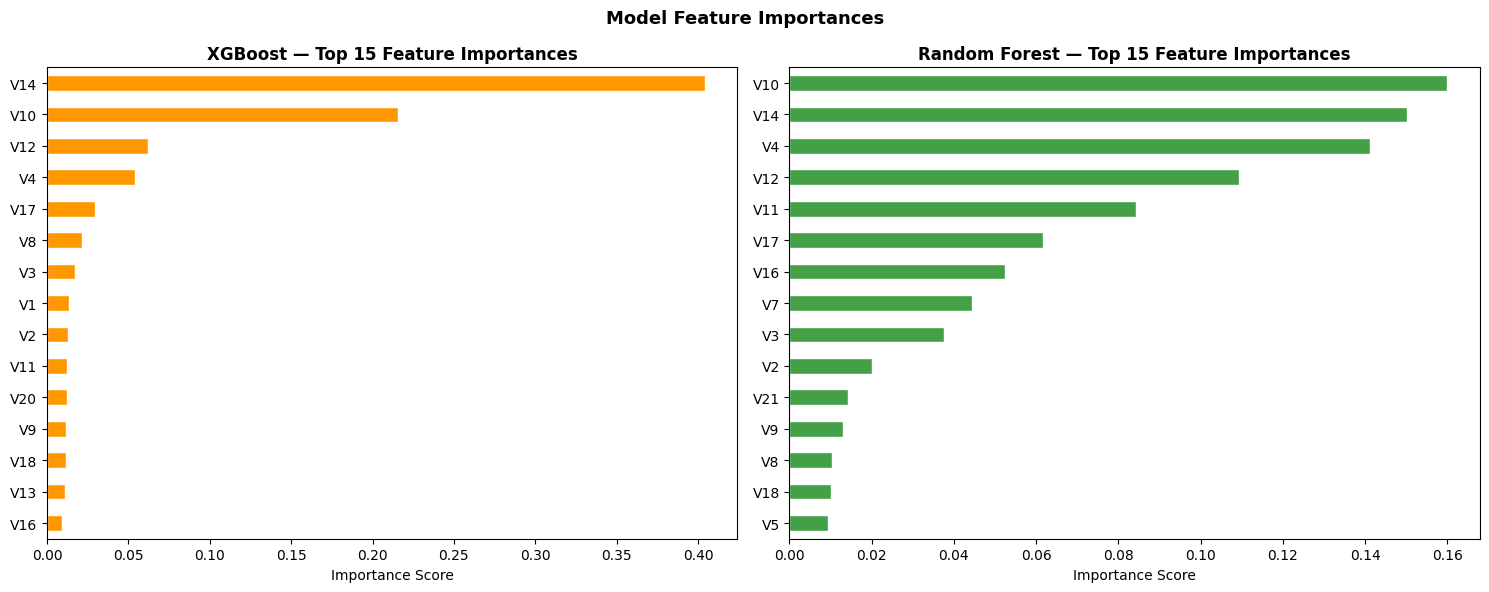

 Feature importances saved


In [24]:
 # SECTION 17: FEATURE IMPORTANCE PLOTS (XGBoost & RF)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(15,6))
fig.suptitle("Model Feature Importances", fontsize=13, fontweight='bold')

feat_imp_xgb_full = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

feat_imp_rf_full = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

feat_imp_xgb_full[::-1].plot(kind='barh', color='#FF9800',
                               edgecolor='white', ax=axes[0])
axes[0].set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
axes[0].set_xlabel('Importance Score')

feat_imp_rf_full[::-1].plot(kind='barh', color='#43A047',
                             edgecolor='white', ax=axes[1])
axes[1].set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Feature importances saved")

In [26]:
# SECTION 18: FINAL COMPARISON TABLE
# ─────────────────────────────────────────────────────────────
import os # Added import for os.path.exists

print("\n" + "="*70)
print("  FINAL PERFORMANCE COMPARISON — ALL METRICS")
print("="*70)

# Define the order of models for consistent printing
model_order = ['ANN', 'XGBoost', 'Random Forest']

# Collect all metric data in a structured way
metric_data = {}
for r in all_results:
    model_name = r['name']
    # Initialize with default 'N/A' for missing CV data
    cv_f1_mean = "N/A"
    cv_f1_std = "N/A"

    # Check if model exists in cv_summary (ANN does not)
    if model_name in cv_summary:
        cv_f1_mean = f"{cv_summary[model_name]['f1_mean']:.4f}"
        cv_f1_std = f"±{cv_summary[model_name]['f1_std']:.4f}"

    metric_data[model_name] = {
        'Accuracy (%)': f"{r['accuracy']*100:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1-Score': f"{r['f1']:.4f}",
        'AUC-ROC': f"{r['auc']:.4f}",
        'FN (missed)': f"{r['cm'][1,0]}",
        'FP (false alarm)': f"{r['cm'][0,1]}",
        'Cost (€)': f"€{r['cm'][1,0]*1000 + r['cm'][0,1]*10:,}",
        'CV F1 Mean': cv_f1_mean,
        'CV F1 SD': cv_f1_std,
        # 'PR-AUC', 'MCC', 'Brier Score' are not consistently available
        # in all_results or easily accessible here without re-running models
    }

# Define the metrics to display and their order
metrics_to_display = [
    'Accuracy (%)', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC',
    'FN (missed)', 'FP (false alarm)', 'Cost (€)',
    'CV F1 Mean', 'CV F1 SD'
]

# Print the header
header = f"{'Metric':<22} {model_order[0]:>12} {model_order[1]:>12} {model_order[2]:>14}"
print(header)
print("-"*70)

# Print data rows
for metric_name in metrics_to_display:
    ann_val = metric_data['ANN'].get(metric_name, 'N/A')
    xgb_val = metric_data['XGBoost'].get(metric_name, 'N/A')
    rf_val  = metric_data['Random Forest'].get(metric_name, 'N/A')
    print(f"{metric_name:<22} {ann_val:>12} {xgb_val:>12} {rf_val:>14}")

print("="*70)

# Create summary DataFrame for display
summary_df_data = {metric_name: [metric_data[model_name][metric_name] for model_name in model_order]
                   for metric_name in metrics_to_display}
summary_df = pd.DataFrame(summary_df_data, index=model_order).T
print("\n");
try:
    display(summary_df)
except NameError:
    print(summary_df.to_string())

print("\n ALL EXPERIMENTS COMPLETE")
print("Generated files:")
files = [
    'eda_plots.png', 'ann_training_curves.png',
    'xgb_feature_importance.png', 'rf_feature_importance.png',
    'Confusion_Matrices_Fraud_Detection.png', 'roc_curves.png',
    'class_balance_experiment.png', 'cost_analysis.png',
    'shap_importance.png', 'shap_summary_xgb.png',
    'robustness_analysis.png', 'calibration_diagrams.png',
    'feature_importances.png'
]
for f in files:
    exists = "✅" if os.path.exists(f) else "❌"
    print(f"  {exists} {f}")


  FINAL PERFORMANCE COMPARISON — ALL METRICS
Metric                          ANN      XGBoost  Random Forest
----------------------------------------------------------------------
Accuracy (%)                99.9701      99.9516        99.9736
Precision                    0.9997       0.9995         0.9997
Recall                       0.9997       0.9995         0.9997
F1-Score                     0.9997       0.9995         0.9997
AUC-ROC                      1.0000       1.0000         1.0000
FN (missed)                       0            0              0
FP (false alarm)                 34           55             30
Cost (€)                       €340         €550           €300
CV F1 Mean                      N/A       0.9992         0.9987
CV F1 SD                        N/A      ±0.0002        ±0.0001




,ANN,XGBoost,Random Forest
Accuracy (%),99.9701,99.9516,99.9736
Precision,0.9997,0.9995,0.9997
Recall,0.9997,0.9995,0.9997
F1-Score,0.9997,0.9995,0.9997
AUC-ROC,1.0000,1.0000,1.0000
FN (missed),0,0,0
FP (false alarm),34,55,30
Cost (€),€340,€550,€300
CV F1 Mean,N/A,0.9992,0.9987
CV F1 SD,N/A,±0.0002,±0.0001



 ALL EXPERIMENTS COMPLETE
Generated files:
  ✅ eda_plots.png
  ✅ ann_training_curves.png
  ✅ xgb_feature_importance.png
  ✅ rf_feature_importance.png
  ❌ Confusion_Matrices_Fraud_Detection.png
  ❌ roc_curves.png
  ✅ class_balance_experiment.png
  ✅ cost_analysis.png
  ✅ shap_importance.png
  ✅ shap_summary_xgb.png
  ✅ robustness_analysis.png
  ✅ calibration_diagrams.png
  ✅ feature_importances.png
